# **Social Media Impact on Teen Mental Health**

In [1]:
import pandas as pd

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report , accuracy_score
from sklearn.preprocessing import  StandardScaler

from imblearn.over_sampling import SMOTE 

import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/ChickenMan-1080/ML-Practice/refs/heads/main/ML-Social_Media_Teen_MentalHealth/assets/Teen_Mental_Health_Dataset.csv')
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [4]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [5]:
print(df.isnull().sum())

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64


In [6]:
df_y = df['depression_label']
df_y = pd.DataFrame(df_y)
df_y

,depression_label
0,0
1,0
2,0
3,0
4,0
...,...
1195,0
1196,0
1197,0
1198,0


In [7]:
df_X = df.drop(df_y,axis=1)
df_X

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9


depression_label
0                   1169
1                     31
Name: count, dtype: int64

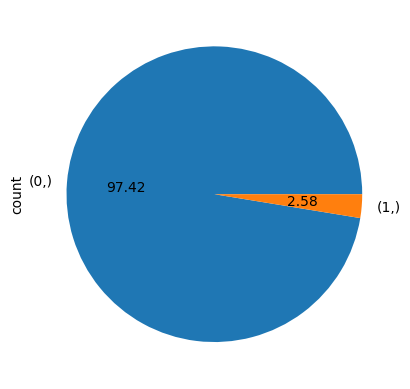

In [8]:
df_y.value_counts().plot.pie(autopct='%.2f')
df_y.value_counts()

ตรงจะติดสินใจทำ Over sampling SMOTE เนื่องจากข้อมูลไม่สมดุลอย่างรุนแรง

<Axes: xlabel='age', ylabel='academic_performance'>

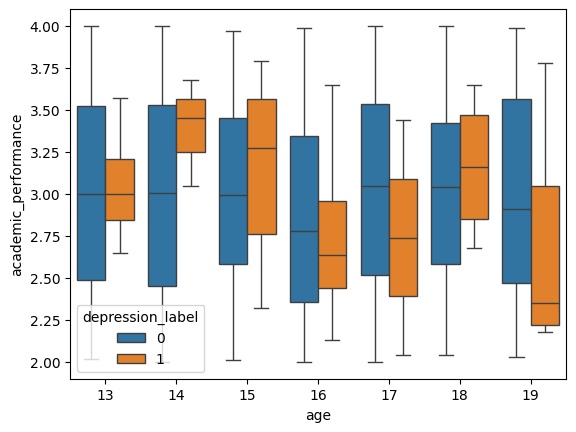

In [9]:
sns.boxplot(data=df,x='age',y='academic_performance',hue='depression_label')

<Axes: xlabel='social_interaction_level', ylabel='academic_performance'>

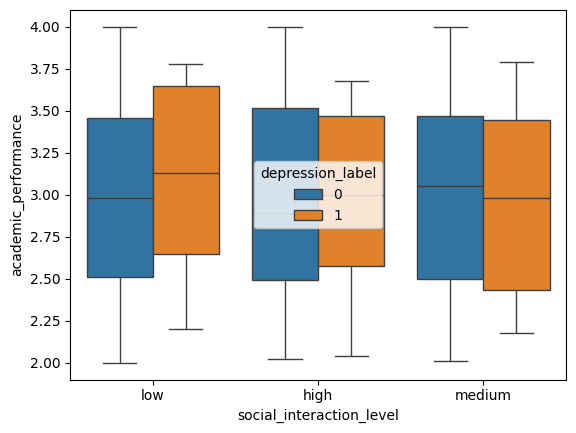

In [10]:
sns.boxplot(df,x='social_interaction_level',y='academic_performance',hue='depression_label')

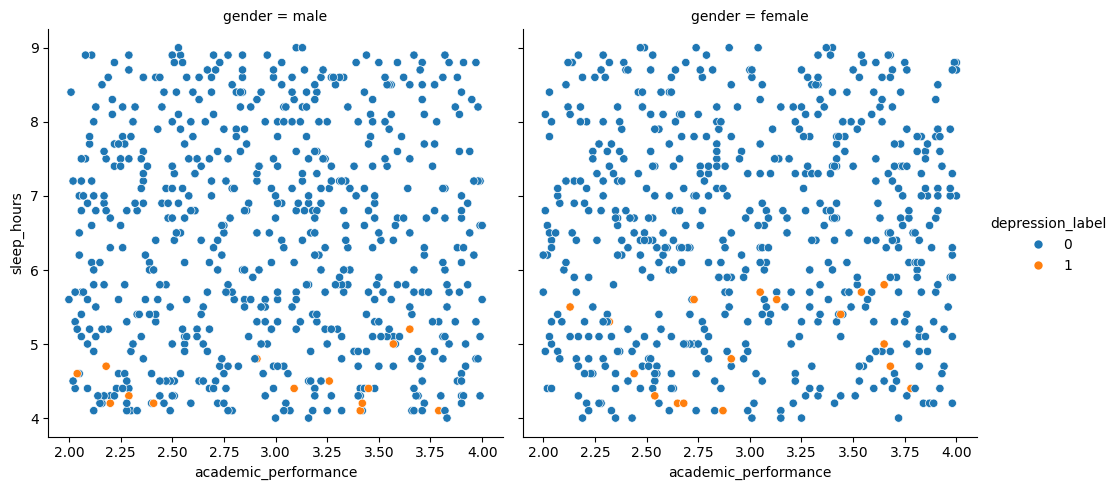

In [11]:
sns.relplot(df,x='academic_performance',y='sleep_hours',hue='depression_label',col='gender')

Sleep_hour เป็น feature ที่แข็งแรงมากบน dataset นี้

# Encode Data

In [12]:
df_encoded = pd.get_dummies(df,columns=['gender','platform_usage','social_interaction_level'],dtype=int)
df_encoded

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_female,gender_male,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_high,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,0,0,1,0,1,0,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,1,0,0,0,1,1,0,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,1,0,0,1,0,1,0,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,0,0,1,0,0,1,0,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,1,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,6.8,6.6,2.0,2.76,1.0,3,4,4,0,1,0,0,1,0,0,1,0
1196,16,2.3,8.0,1.9,2.12,0.4,7,4,4,0,0,1,1,0,0,1,0,0
1197,14,1.7,8.7,0.7,3.98,0.8,1,1,1,0,1,0,1,0,0,1,0,0
1198,15,3.9,8.5,2.1,3.19,0.6,7,9,9,0,0,1,1,0,0,1,0,0


# Split Data

In [13]:
df_encoded_X = df_encoded.drop(['depression_label'],axis=1)
df_encoded_y = df_encoded['depression_label']

df_encoded_y


0       0
1       0
2       0
3       0
4       0
       ..
1195    0
1196    0
1197    0
1198    0
1199    0
Name: depression_label, Length: 1200, dtype: int64

In [14]:
X_train,X_test,y_train,y_test = train_test_split(df_encoded_X,df_encoded_y,test_size=0.2,random_state=42)

# Scaler

In [15]:
'''scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)'''

'scaler = StandardScaler()\nX_train_scaled = scaler.fit_transform(X_train)'

# SMOTE

In [16]:
smote = SMOTE(random_state=42)

In [17]:
X_resampled, y_resampled = smote.fit_resample(X_train,y_train)
X_resampled

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,gender_female,gender_male,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_high,social_interaction_level_low,social_interaction_level_medium
0,16,6.100000,8.100000,1.400000,3.270000,1.600000,10,1,4,1,0,0,1,0,0,1,0
1,15,5.700000,7.500000,2.400000,2.840000,1.300000,10,10,2,1,0,0,1,0,0,0,1
2,13,1.100000,7.100000,1.800000,2.550000,0.800000,5,5,10,0,1,0,0,1,1,0,0
3,16,5.300000,4.300000,1.500000,2.540000,0.300000,7,7,10,1,0,0,0,1,1,0,0
4,14,6.400000,6.000000,1.100000,3.810000,0.900000,8,2,3,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1865,15,5.389061,5.644531,2.410939,2.872498,1.300000,7,9,4,1,0,1,0,0,0,0,1
1866,13,7.248518,4.151482,2.305927,2.756740,1.017781,10,9,2,1,0,0,0,0,0,1,0
1867,14,6.901917,4.379617,1.740767,3.513401,0.646620,10,7,9,0,0,1,0,0,0,0,0
1868,16,5.951279,4.910574,1.133656,2.991825,0.381410,8,7,10,1,0,0,0,0,1,0,0


In [18]:
classX_count = pd.DataFrame(y_resampled)
classX_count

,depression_label
0,0
1,0
2,0
3,1
4,0
...,...
1865,1
1866,1
1867,1
1868,1


In [19]:
model = LogisticRegression(max_iter=3000,random_state = 42,class_weight='balanced')
model.fit(X_resampled,y_resampled)
#y_pred_smote = model.predict(X_test)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [25]:
# ใช้ predict_proba แทน → ได้ probability ออกมา
y_proba_smote = model.predict_proba(X_test)[:, 1]  # เอาแค่ prob ของ class 1

# ปรับ threshold เอง (ค่า default ของ sklearn คือ 0.5)
threshold = 0.7  # ลองปรับตรงนี้
y_pred_custom = (y_proba_smote >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       234
           1       0.40      0.67      0.50         6

    accuracy                           0.97       240
   macro avg       0.70      0.82      0.74       240
weighted avg       0.98      0.97      0.97       240



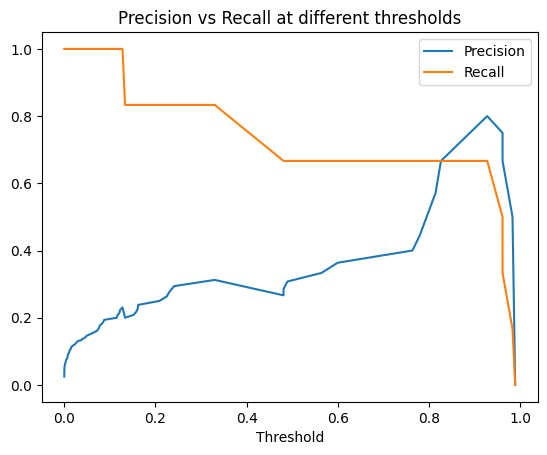

In [21]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_smote)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision vs Recall at different thresholds')
plt.show()

# Evaluation Mericx

In [22]:
print(f'Accuracy : {accuracy_score(y_test,y_pred_smote)}')

NameError: name 'y_pred_smote' is not defined

In [ ]:
print(classification_report(y_test,y_pred_smote))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.36      0.83      0.50         6

    accuracy                           0.96       240
   macro avg       0.68      0.90      0.74       240
weighted avg       0.98      0.96      0.97       240



<Axes: >

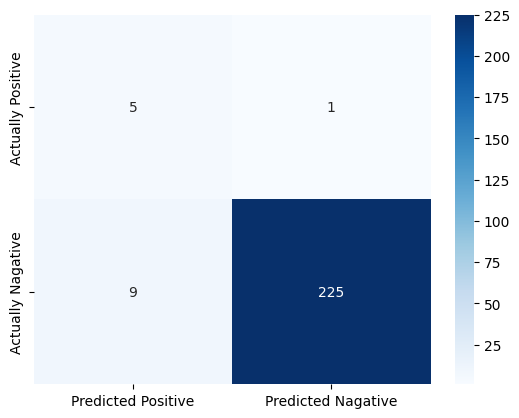

In [ ]:
cm = confusion_matrix(y_test,y_pred_smote,labels=[1,0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',yticklabels=['Actually Positive','Actually Nagative'],xticklabels=['Predicted Positive','Predicted Nagative'])

In [ ]:
print("Classes order:", model.classes_)
print("Confusion Matrix:\n", cm)
print("y_test unique values:", y_test.unique())

Classes order: [0 1]
Confusion Matrix:
 [[  5   1]
 [  9 225]]
y_test unique values: [0 1]


In [ ]:
import numpy as np

importance = model.coef_[0]
feature_names = X_resampled.columns

# 2. สร้าง DataFrame เพื่อให้ดูง่ายและเรียงลำดับ
feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# เรียงลำดับตามขนาด (Absolute Value) เพื่อดูว่าตัวไหนมีผลมากสุด
feat_importance['Abs_Importance'] = feat_importance['Importance'].abs()
feat_importance = feat_importance.sort_values(by='Abs_Importance', ascending=False)

/tmp/ipykernel_36582/957262467.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_importance, palette='viridis')


                            Feature  Importance
13     social_interaction_level_low   -2.543628
12    social_interaction_level_high   -2.489958
8                       gender_male   -2.472818
10         platform_usage_Instagram   -2.450985
1                       sleep_hours   -2.316566
11            platform_usage_TikTok   -1.769672
14  social_interaction_level_medium   -1.570915
9               platform_usage_Both   -1.280426
0          daily_social_media_hours    1.162631
5                     anxiety_level    0.912367
4                      stress_level    0.797601
3                 physical_activity   -0.626417
2          screen_time_before_sleep   -0.235402
7                     gender_female   -0.227962
6                   addiction_level    0.006059


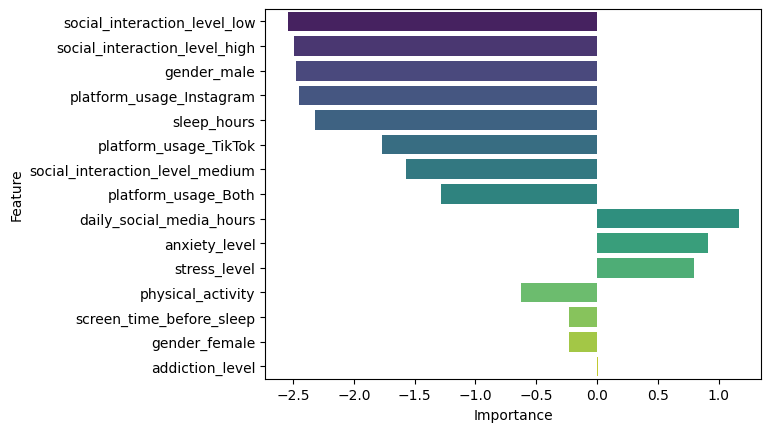

In [ ]:
sns.barplot(x='Importance', y='Feature', data=feat_importance, palette='viridis')
print(feat_importance[['Feature', 'Importance']])

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#คำนวณค่า VIF สำหรับแต่ละ Feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_resampled.columns
vif_data["VIF"] = [variance_inflation_factor(X_resampled.values, i) for i in range(len(X_resampled.columns))]

#เรียงลำดับจากมากไปน้อย
print(vif_data.sort_values(by="VIF", ascending=False))

                            Feature        VIF
1                       sleep_hours  18.413458
0          daily_social_media_hours  11.069281
5                     anxiety_level   9.378120
4                      stress_level   8.719974
2          screen_time_before_sleep   7.587195
3                 physical_activity   4.622103
6                   addiction_level   4.017573
7                     gender_female   3.829951
8                       gender_male   3.509385
14  social_interaction_level_medium   2.521098
13     social_interaction_level_low   2.395128
12    social_interaction_level_high   2.344710
10         platform_usage_Instagram   2.296237
11            platform_usage_TikTok   2.271591
9               platform_usage_Both   2.269903


AUC Score: 0.9744


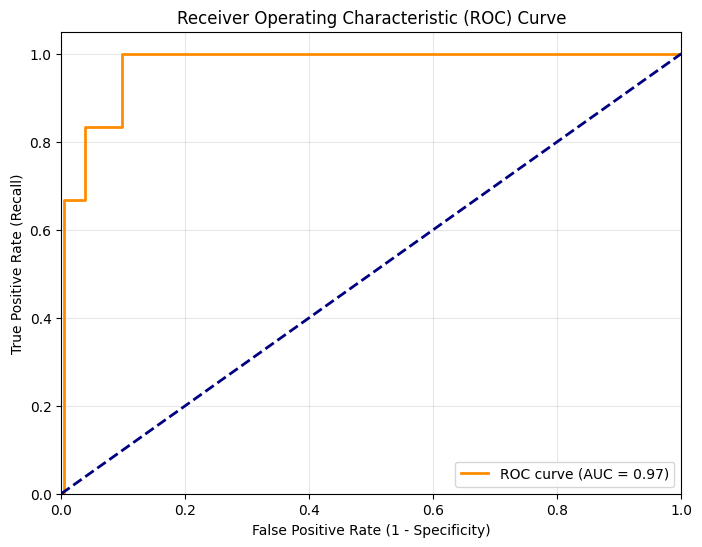

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# 1. ดึงค่าความน่าจะเป็น (Probability) ของคลาส 1
y_probs = model.predict_proba(X_test)[:, 1]

# 2. คำนวณค่า AUC Score
auc_value = roc_auc_score(y_test, y_probs)
print(f"AUC Score: {auc_value:.4f}")

# 3. คำนวณค่าสำหรับพล็อตกราฟ ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# 4. พล็อตกราฟ
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # เส้นทแยงมุม (Baseline ของการเดาสุ่ม)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

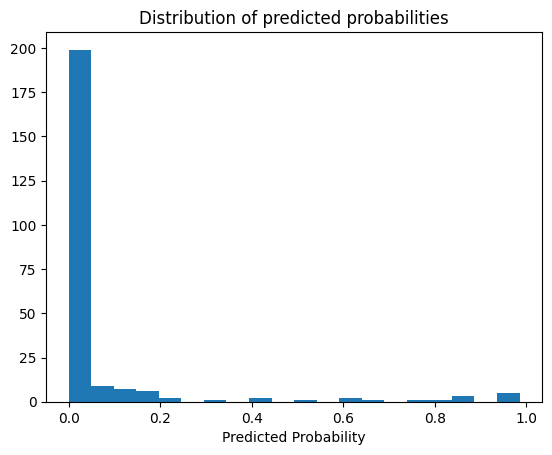

In [ ]:
# ดูการกระจายของ probability
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test)[:, 1]
plt.hist(y_proba, bins=20)
plt.xlabel('Predicted Probability')
plt.title('Distribution of predicted probabilities')
plt.show()